# Financial Forecasting Frontier: Distributed Machine Learning

## Data Analysis and Management using Hadoop & Hive

### Project Objective

To demonstrate distributed data storage, processing, and analytical capabilities using Hadoop and Hive on banking customer data. The project focuses on managing large-scale banking information, performing data transformations, and generating business insights through distributed computing techniques.

### Project Goal

The primary goal of this project is to explore how distributed computing technologies can be applied to banking datasets for efficient data management, querying, and analysis. The project simulates real-world banking scenarios where large volumes of customer information must be processed to support business decision-making.

### Dataset Overview

The dataset contains banking customer information including demographic details, account balances, loan status, campaign interactions, and term deposit subscription outcomes.

### Technologies Used

* Hadoop
* Hive
* Apache Spark
* Python
* Google Colab
* Pandas

### Business Problem

Banks generate large volumes of customer data that must be processed efficiently. Traditional single-machine processing can become inefficient as data grows. Distributed technologies help organizations manage, analyze, and derive actionable insights from banking data at scale.

### GitHub Repository

GitHub Link: [Link](https://github.com/Aks18had/Financial-Forecasting-Frontier-Distributed-ML)

### Dataset Source

 By Alma better.


In [ ]:
from google.colab import drive # Mounting the Gdrive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd #Importing libraries

DATA_PATH = "/content/drive/MyDrive/Distributed_ML_Project/bank.csv"  # Giving data Path

df = pd.read_csv(DATA_PATH)

print("Dataset Loaded Successfully")
print("Shape:", df.shape)

df.head() # Viewing that dataset has loaded and giving response

Dataset Loaded Successfully
Shape: (4521, 17)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,30,unemployed,married,primary,no,1787,no,no,cellular,19,oct,79,1,-1,0,unknown,no
1,33,services,married,secondary,no,4789,yes,yes,cellular,11,may,220,1,339,4,failure,no
2,35,management,single,tertiary,no,1350,yes,no,cellular,16,apr,185,1,330,1,failure,no
3,30,management,married,tertiary,no,1476,yes,yes,unknown,3,jun,199,4,-1,0,unknown,no
4,59,blue-collar,married,secondary,no,0,yes,no,unknown,5,may,226,1,-1,0,unknown,no


## Question 1: Data Ingestion

### Objective
Simulate the process of ingesting banking data into a distributed environment. The dataset is loaded from Google Drive and prepared for further distributed processing and analysis.

In [ ]:
# Question 1: Data Ingestion

import pandas as pd

DATA_PATH = "/content/drive/MyDrive/Distributed_ML_Project/bank.csv"

df = pd.read_csv(DATA_PATH) # Giving the data path

print("Dataset Successfully Ingested")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

df.head()

Dataset Successfully Ingested
Rows: 4521
Columns: 17


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,30,unemployed,married,primary,no,1787,no,no,cellular,19,oct,79,1,-1,0,unknown,no
1,33,services,married,secondary,no,4789,yes,yes,cellular,11,may,220,1,339,4,failure,no
2,35,management,single,tertiary,no,1350,yes,no,cellular,16,apr,185,1,330,1,failure,no
3,30,management,married,tertiary,no,1476,yes,yes,unknown,3,jun,199,4,-1,0,unknown,no
4,59,blue-collar,married,secondary,no,0,yes,no,unknown,5,may,226,1,-1,0,unknown,no


## Question 2(A): Average Account Balance for Each Job Type

### Objective
Calculate the average account balance for each job category using a MapReduce-inspired approach.

### Map Phase
Group records by job type and collect balance values.

### Reduce Phase
Calculate the average balance for each job category.

In [ ]:
# Question 2(A) For my refrence

avg_balance_job = (
    df.groupby("job")["balance"]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

avg_balance_job.columns = ["Job Type", "Average Balance"]

print("Average Account Balance by Job Type:")
avg_balance_job

Average Account Balance by Job Type:


,Job Type,Average Balance
0,retired,2319.191304
1,housemaid,2083.803571
2,management,1766.928793
3,entrepreneur,1645.125000
4,student,1543.821429
5,unknown,1501.710526
6,self-employed,1392.409836
7,technician,1330.996094
8,admin.,1226.736402
9,services,1103.956835


<Figure size 1000x600 with 0 Axes>

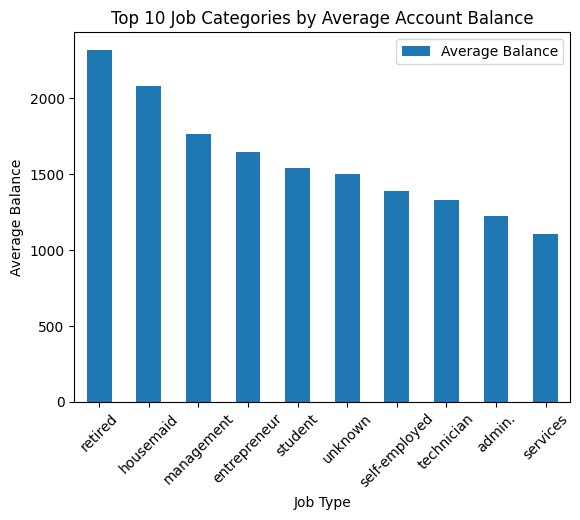

In [ ]:
import matplotlib.pyplot as plt # Importing matplotlib for data visualization

plt.figure(figsize=(10,6)) # Using Bar Chart here

avg_balance_job.sort_values(
    "Average Balance",
    ascending=False
).head(10).plot(
    x="Job Type",
    y="Average Balance",
    kind="bar"
)

plt.title("Top 10 Job Categories by Average Account Balance")
plt.ylabel("Average Balance")
plt.xlabel("Job Type")
plt.xticks(rotation=45)

plt.show()

## Question 2(B): Housing Loan Status by Education Level

### Objective
Analyze the distribution of clients with and without housing loans across different education levels using a MapReduce-inspired aggregation approach.

### Map Phase
Group records by education level and housing loan status.

### Reduce Phase
Count the number of clients in each category.

In [ ]:
housing_education = (
    df.groupby(["education", "housing"])
      .size()
      .reset_index(name="Count")
)

print("Housing Loan Distribution by Education Level")
housing_education


Housing Loan Distribution by Education Level


,education,housing,Count
0,primary,no,295
1,primary,yes,383
2,secondary,no,876
3,secondary,yes,1430
4,tertiary,no,687
5,tertiary,yes,663
6,unknown,no,104
7,unknown,yes,83


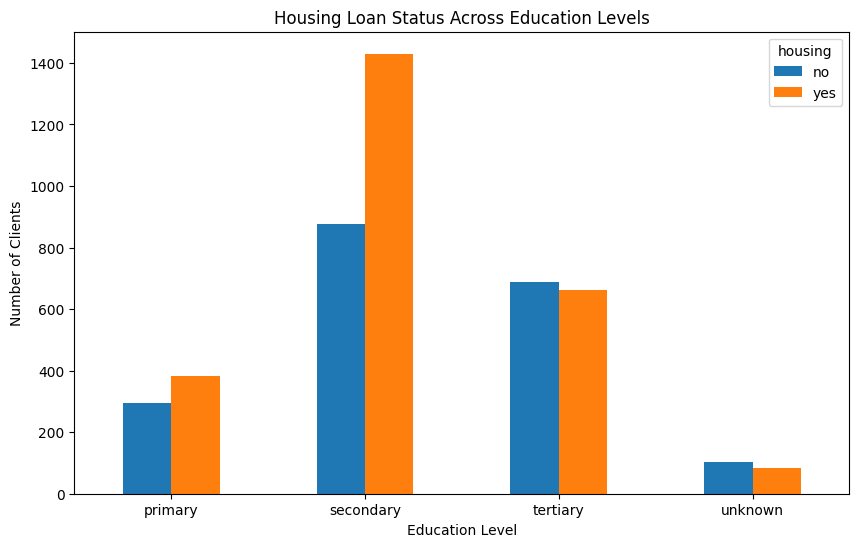

In [ ]:
import matplotlib.pyplot as plt # Bar chart has displayed
import pandas as pd

pivot_table = pd.pivot_table(
    housing_education,
    values="Count",
    index="education",
    columns="housing"
)

pivot_table.plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Housing Loan Status Across Education Levels")
plt.xlabel("Education Level")
plt.ylabel("Number of Clients")
plt.xticks(rotation=0)
plt.show()

## Question 2(C): Monthly Contacts and Subscription Status

### Objective
Analyze the number of clients contacted during each month and evaluate their term deposit subscription status.

### Map Phase
Group records by month and subscription outcome.

### Reduce Phase
Count the number of clients in each category.

In [ ]:
monthly_contacts = (
    df.groupby(["month", "y"])
      .size()
      .reset_index(name="Count")
)

print("Monthly Contacts and Subscription Status")
monthly_contacts

Monthly Contacts and Subscription Status


,month,y,Count
0,apr,no,237
1,apr,yes,56
2,aug,no,554
3,aug,yes,79
4,dec,no,11
5,dec,yes,9
6,feb,no,184
7,feb,yes,38
8,jan,no,132
9,jan,yes,16


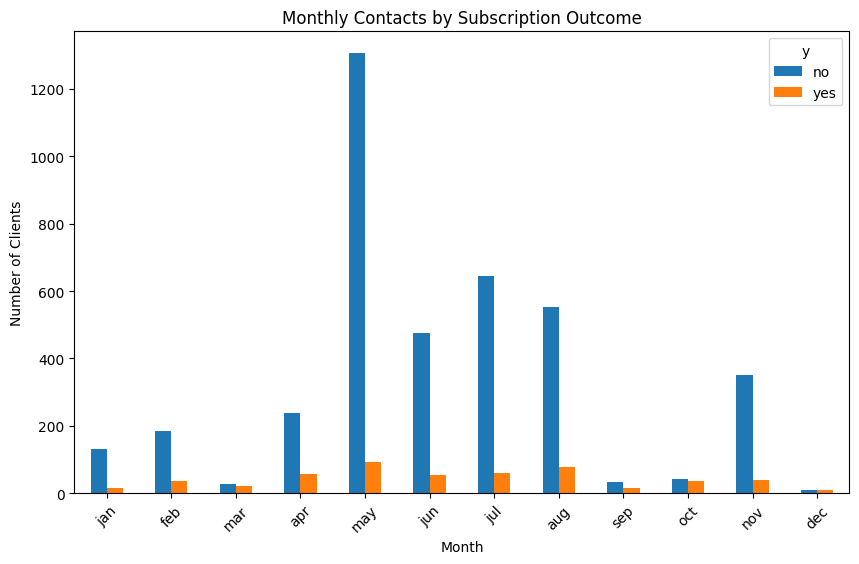

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

monthly_pivot = pd.pivot_table(
    monthly_contacts,
    values="Count",
    index="month",
    columns="y"
)

month_order = [
    "jan","feb","mar","apr","may","jun",
    "jul","aug","sep","oct","nov","dec"
]

monthly_pivot = monthly_pivot.reindex(
    [m for m in month_order if m in monthly_pivot.index]
)

monthly_pivot.plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Monthly Contacts by Subscription Outcome")
plt.xlabel("Month")
plt.ylabel("Number of Clients")
plt.xticks(rotation=45)
plt.show()

## Question 3(A): Average Contact Duration by Campaign Outcome

### Objective
Analyze the average duration of customer contacts for different outcomes of previous marketing campaigns.

### Map Phase
Group records by campaign outcome (poutcome).

### Reduce Phase
Calculate the average contact duration for each campaign outcome.

In [ ]:
duration_poutcome = (
    df.groupby("poutcome")["duration"]
      .mean()
      .sort_values(ascending=False)
      .reset_index()
)

duration_poutcome.columns = [
    "Campaign Outcome",
    "Average Duration"
]

print("Average Contact Duration by Campaign Outcome")
duration_poutcome

Average Contact Duration by Campaign Outcome


,Campaign Outcome,Average Duration
0,success,338.635659
1,other,273.832487
2,unknown,262.103104
3,failure,254.383673


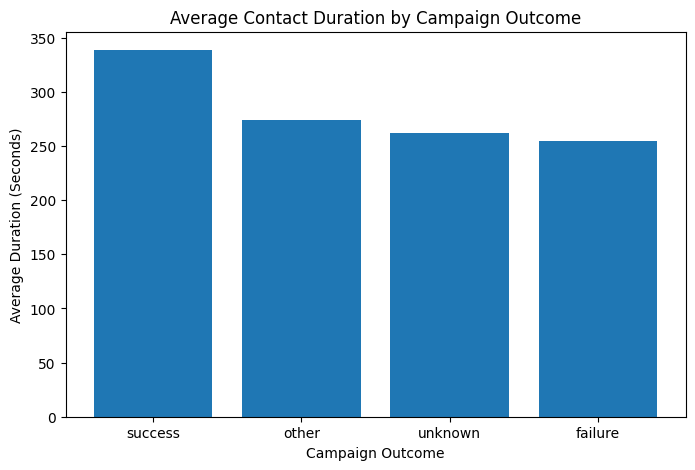

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(
    duration_poutcome["Campaign Outcome"],
    duration_poutcome["Average Duration"]
)

plt.title("Average Contact Duration by Campaign Outcome")
plt.xlabel("Campaign Outcome")
plt.ylabel("Average Duration (Seconds)")
plt.show()

## Question 3(B): Relationship Between Age and Account Balance

### Objective
Examine whether there is a relationship between a client's age and their account balance.

### Map Phase
Extract age and balance information from each client record.

### Reduce Phase
Calculate the correlation and visualize the relationship between the two variables.

In [ ]:
correlation = df["age"].corr(df["balance"]) #Correlation is used to calculate the relationship between two variables

print(f"Correlation between Age and Balance: {correlation:.4f}")

Correlation between Age and Balance: 0.0838


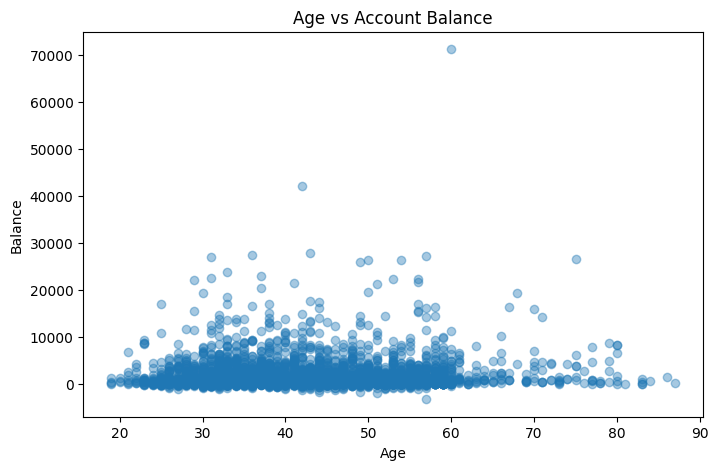

In [ ]:
import matplotlib.pyplot as plt # Scatter plot is used here

plt.figure(figsize=(8,5))

plt.scatter(
    df["age"],
    df["balance"],
    alpha=0.4
)

plt.title("Age vs Account Balance")
plt.xlabel("Age")
plt.ylabel("Balance")

plt.show()

# HIVE ANALYSIS

This section simulates Hive-style data warehousing and analytical querying operations on the banking dataset. The objective is to demonstrate how structured querying can be used to derive business insights from banking data.

## Hive Question 1: Data Ingestion and Table Creation

### Objective
Simulate Hive database creation, table definition, and data loading operations for banking data analysis.

### Database Name
banking_data

### Table Name
client_info

In [ ]:
# Simulated Hive Database and Table Creation

database_name = "banking_data"
table_name = "client_info"

print(f"Database Created: {database_name}")
print(f"Table Created: {table_name}")

print("\nLoading Dataset into client_info table...")

client_info = df.copy()

print("Data Loaded Successfully")
print("Rows:", client_info.shape[0])
print("Columns:", client_info.shape[1])

client_info.head()

Database Created: banking_data
Table Created: client_info

Loading Dataset into client_info table...
Data Loaded Successfully
Rows: 4521
Columns: 17


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,30,unemployed,married,primary,no,1787,no,no,cellular,19,oct,79,1,-1,0,unknown,no
1,33,services,married,secondary,no,4789,yes,yes,cellular,11,may,220,1,339,4,failure,no
2,35,management,single,tertiary,no,1350,yes,no,cellular,16,apr,185,1,330,1,failure,no
3,30,management,married,tertiary,no,1476,yes,yes,unknown,3,jun,199,4,-1,0,unknown,no
4,59,blue-collar,married,secondary,no,0,yes,no,unknown,5,may,226,1,-1,0,unknown,no


In [ ]:
print("Table Schema")

client_info.dtypes

Table Schema


,0
age,int64
job,object
marital,object
education,object
default,object
balance,int64
housing,object
loan,object
contact,object
day,int64


## Hive Question 2(A): Count Total Number of Clients

### Objective
Determine the total number of client records available in the banking dataset.

In [ ]:
total_clients = len(client_info)

print("Total Number of Clients:", total_clients)

Total Number of Clients: 4521


## Hive Question 2(B): Display First 10 Rows

### Objective
Inspect the first ten records of the banking dataset to understand its structure and available attributes.

In [ ]:
client_info.head(10)

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,30,unemployed,married,primary,no,1787,no,no,cellular,19,oct,79,1,-1,0,unknown,no
1,33,services,married,secondary,no,4789,yes,yes,cellular,11,may,220,1,339,4,failure,no
2,35,management,single,tertiary,no,1350,yes,no,cellular,16,apr,185,1,330,1,failure,no
3,30,management,married,tertiary,no,1476,yes,yes,unknown,3,jun,199,4,-1,0,unknown,no
4,59,blue-collar,married,secondary,no,0,yes,no,unknown,5,may,226,1,-1,0,unknown,no
5,35,management,single,tertiary,no,747,no,no,cellular,23,feb,141,2,176,3,failure,no
6,36,self-employed,married,tertiary,no,307,yes,no,cellular,14,may,341,1,330,2,other,no
7,39,technician,married,secondary,no,147,yes,no,cellular,6,may,151,2,-1,0,unknown,no
8,41,entrepreneur,married,tertiary,no,221,yes,no,unknown,14,may,57,2,-1,0,unknown,no
9,43,services,married,primary,no,-88,yes,yes,cellular,17,apr,313,1,147,2,failure,no


## Hive Question 3(A): Married Clients with Personal Loans

### Objective
Identify clients who are married and currently have a personal loan.

In [ ]:
married_loan_clients = client_info[
    (client_info["marital"] == "married") &
    (client_info["loan"] == "yes")
]

print("Total Married Clients with Personal Loan:",
      len(married_loan_clients))

married_loan_clients.head(10)

Total Married Clients with Personal Loan: 453


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
1,33,services,married,secondary,no,4789,yes,yes,cellular,11,may,220,1,339,4,failure,no
3,30,management,married,tertiary,no,1476,yes,yes,unknown,3,jun,199,4,-1,0,unknown,no
9,43,services,married,primary,no,-88,yes,yes,cellular,17,apr,313,1,147,2,failure,no
14,31,blue-collar,married,secondary,no,360,yes,yes,cellular,29,jan,89,1,241,1,failure,no
15,40,management,married,tertiary,no,194,no,yes,cellular,29,aug,189,2,-1,0,unknown,no
28,56,self-employed,married,secondary,no,784,no,yes,cellular,30,jul,149,2,-1,0,unknown,no
29,53,admin.,married,secondary,no,105,no,yes,cellular,21,aug,74,2,-1,0,unknown,no
56,57,management,married,secondary,no,82,no,yes,telephone,4,feb,140,1,-1,0,unknown,no
60,41,blue-collar,married,primary,no,-516,no,yes,telephone,8,jul,554,3,-1,0,unknown,no
68,41,management,married,secondary,no,0,no,yes,cellular,7,jul,630,3,-1,0,unknown,no


## Hive Question 3(B): Top 10 Clients with Highest Balance

### Objective
Identify the customers with the highest account balances and analyze their demographic characteristics.

In [ ]:
top_balance_clients = (
    client_info[
        ["job", "marital", "balance"]
    ]
    .sort_values(
        by="balance",
        ascending=False
    )
    .head(10)
)

top_balance_clients

,job,marital,balance
3700,retired,married,71188
2989,entrepreneur,married,42045
1483,technician,single,27733
1881,management,married,27359
3830,technician,married,27069
871,housemaid,single,26965
4047,retired,married,26452
3011,services,married,26394
2196,management,divorced,26306
1031,retired,single,25824


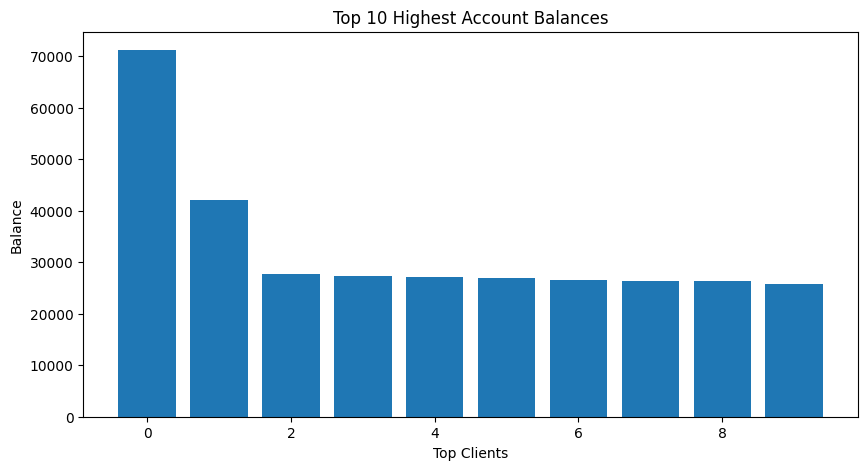

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.bar(
    range(len(top_balance_clients)),
    top_balance_clients["balance"]
)

plt.title("Top 10 Highest Account Balances")
plt.xlabel("Top Clients")
plt.ylabel("Balance")

plt.show()

## Hive Question 4(A): Average Age by Job Category

### Objective
Analyze the average age of clients across different job categories.

In [ ]:
avg_age_job = (
    client_info.groupby("job")["age"]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

avg_age_job.columns = ["Job Type", "Average Age"]

avg_age_job

,Job Type,Average Age
0,retired,61.869565
1,unknown,48.105263
2,housemaid,47.339286
3,entrepreneur,42.011905
4,self-employed,41.453552
5,unemployed,40.906250
6,management,40.540764
7,blue-collar,40.156448
8,admin.,39.682008
9,technician,39.470052


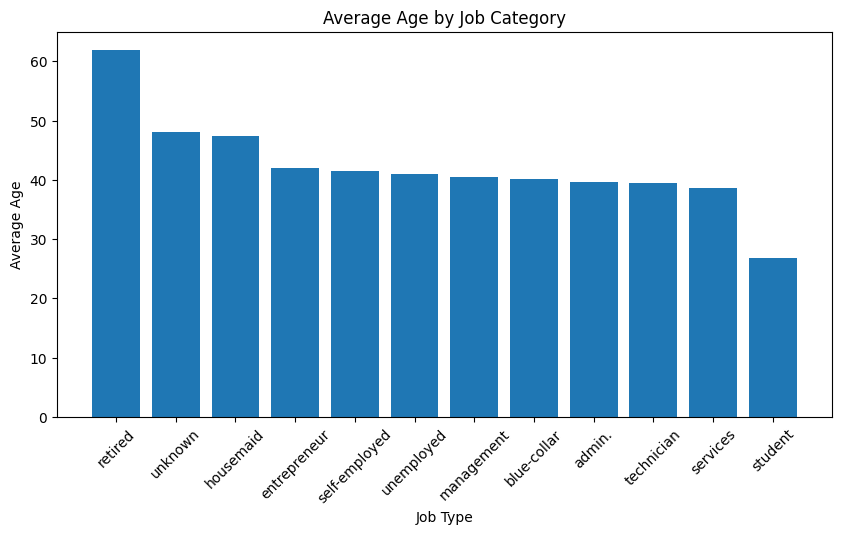

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.bar(
    avg_age_job["Job Type"],
    avg_age_job["Average Age"]
)

plt.title("Average Age by Job Category")
plt.xlabel("Job Type")
plt.ylabel("Average Age")

plt.xticks(rotation=45)

plt.show()

## Hive Question 4(B): Credit Defaults by Education Level

### Objective
Determine how credit defaults are distributed across education levels.

In [ ]:
default_education = (
    client_info[
        client_info["default"] == "yes"
    ]
    .groupby("education")
    .size()
    .reset_index(name="Default Count")
)

default_education

,education,Default Count
0,primary,10
1,secondary,46
2,tertiary,17
3,unknown,3


## Hive Question 5(A): Top 5 Job Categories by Average Balance and Subscription Rate

### Objective
Identify the job categories with the highest average account balances and evaluate their term deposit subscription rates.

In [ ]:
# Average balance by job

avg_balance_job = (
    client_info.groupby("job")["balance"]
    .mean()
    .reset_index()
)

# Subscription rate by job

subscription_rate = (
    client_info.groupby("job")["y"]
    .apply(lambda x: (x == "yes").mean() * 100)
    .reset_index(name="Subscription Rate (%)")
)

# Merge results

job_analysis = pd.merge(
    avg_balance_job,
    subscription_rate,
    on="job"
)

top5_jobs = (
    job_analysis
    .sort_values("balance", ascending=False)
    .head(5)
)

top5_jobs.columns = [
    "Job Type",
    "Average Balance",
    "Subscription Rate (%)"
]

top5_jobs

,Job Type,Average Balance,Subscription Rate (%)
5,retired,2319.191304,23.478261
3,housemaid,2083.803571,12.500000
4,management,1766.928793,13.519092
2,entrepreneur,1645.125000,8.928571
8,student,1543.821429,22.619048


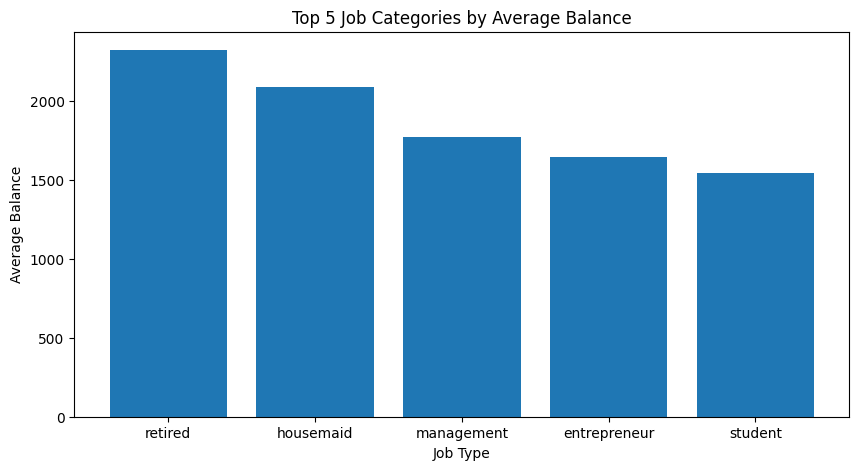

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.bar(
    top5_jobs["Job Type"],
    top5_jobs["Average Balance"]
)

plt.title("Top 5 Job Categories by Average Balance")
plt.xlabel("Job Type")
plt.ylabel("Average Balance")

plt.show()

## Hive Question 5(B): Month with Highest Contacts and Campaign Success Rate

### Objective
Identify the month with the highest client contact volume and evaluate the campaign success rate during that period.

In [ ]:
monthly_stats = (
    client_info.groupby("month")
    .agg(
        Total_Contacts=("month", "count"),
        Success_Rate=("y",
                      lambda x: (x == "yes").mean() * 100) # Using lambda function here
    )
    .reset_index()
)

monthly_stats

,month,Total_Contacts,Success_Rate
0,apr,293,19.112628
1,aug,633,12.480253
2,dec,20,45.000000
3,feb,222,17.117117
4,jan,148,10.810811
5,jul,706,8.640227
6,jun,531,10.357815
7,mar,49,42.857143
8,may,1398,6.652361
9,nov,389,10.025707


In [ ]:
highest_contact_month = monthly_stats.loc[
    monthly_stats["Total_Contacts"].idxmax()
]

print("Month with Highest Contacts:")
print(highest_contact_month)

Month with Highest Contacts:
month                  may
Total_Contacts        1398
Success_Rate      6.652361
Name: 8, dtype: object


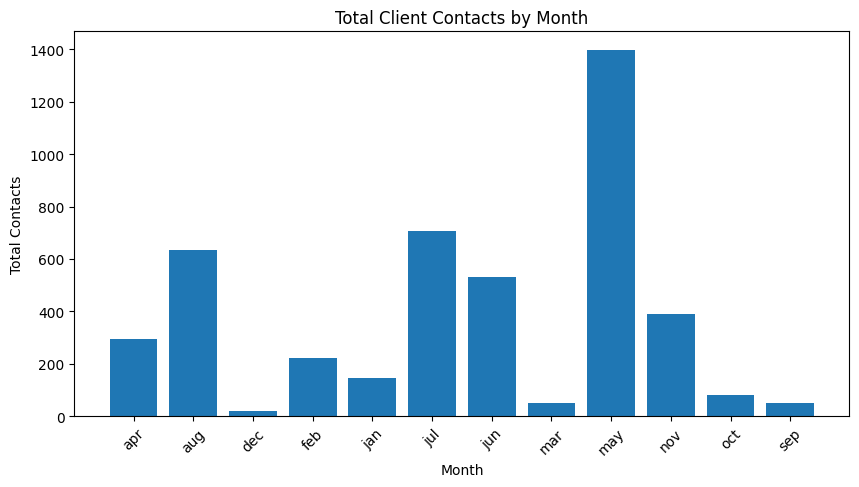

In [ ]:
plt.figure(figsize=(10,5))

plt.bar(
    monthly_stats["month"],
    monthly_stats["Total_Contacts"]
)

plt.title("Total Client Contacts by Month")
plt.xlabel("Month")
plt.ylabel("Total Contacts")

plt.xticks(rotation=45)

plt.show()

## Hive Question 6: Correlation Analysis

### Objective
Determine whether a relationship exists between client age and account balance using correlation analysis.

In [ ]:
correlation = client_info["age"].corr(client_info["balance"])

print(f"Correlation between Age and Balance: {correlation:.4f}")

Correlation between Age and Balance: 0.0838


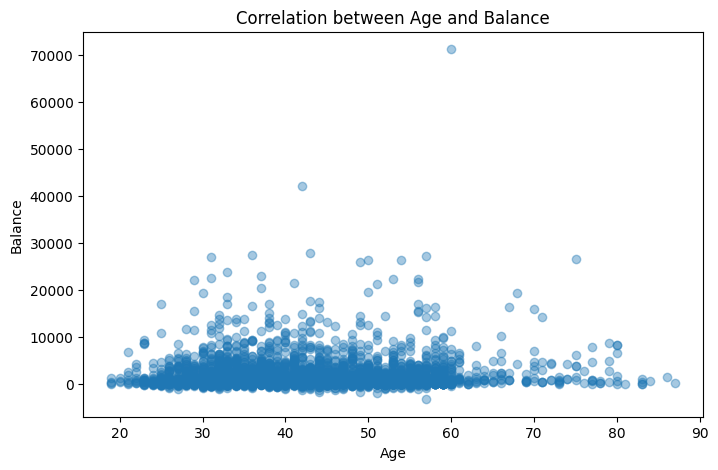

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.scatter(
    client_info["age"],
    client_info["balance"],
    alpha=0.4
)

plt.title("Correlation between Age and Balance")
plt.xlabel("Age")
plt.ylabel("Balance")

plt.show()

## Hive Question 7: Trend Analysis

### Objective
Analyze contact trends within the available dataset.

### Note
The dataset does not contain year information. Therefore, a monthly contact trend analysis is performed as an alternative.

In [ ]:
monthly_trend = (
    client_info.groupby("month")
    .size()
    .reset_index(name="Contact Count")
)

monthly_trend

,month,Contact Count
0,apr,293
1,aug,633
2,dec,20
3,feb,222
4,jan,148
5,jul,706
6,jun,531
7,mar,49
8,may,1398
9,nov,389


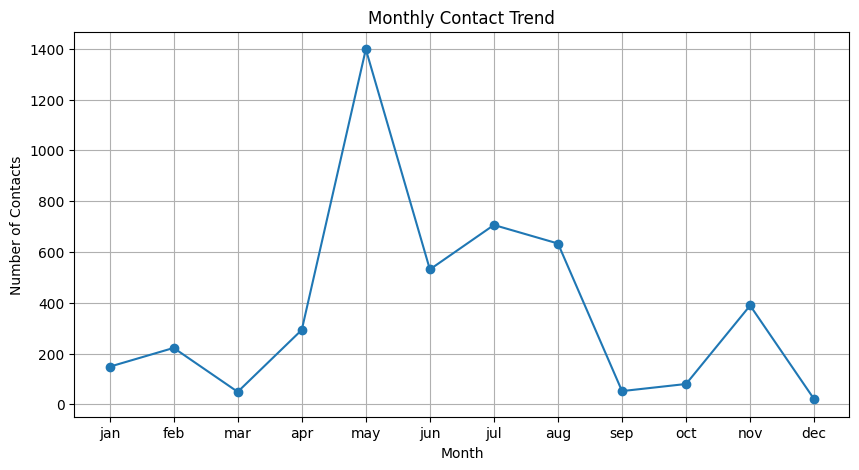

In [ ]:
month_order = [
    "jan","feb","mar","apr","may","jun",
    "jul","aug","sep","oct","nov","dec"
]

monthly_trend["month"] = pd.Categorical(
    monthly_trend["month"],
    categories=month_order,
    ordered=True
)

monthly_trend = monthly_trend.sort_values("month")

plt.figure(figsize=(10,5))

plt.plot(
    monthly_trend["month"],
    monthly_trend["Contact Count"],
    marker="o"
)

plt.title("Monthly Contact Trend")
plt.xlabel("Month")
plt.ylabel("Number of Contacts")

plt.grid(True)
plt.show()

## Hive Question 8: Anomaly Detection

### Objective
Identify unusual patterns in customer balances across education levels.

### Note
The dataset does not contain yearly information. Therefore, anomaly detection is performed using average account balances across education categories.

In [ ]:
education_balance = (
    client_info.groupby("education")["balance"]
    .agg(["mean", "median", "max", "min"])
    .reset_index()
)

education_balance

,education,mean,median,max,min
0,primary,1411.544248,404.5,71188,-966
1,secondary,1196.814397,385.5,26452,-2082
2,tertiary,1775.423704,583.5,42045,-3313
3,unknown,1701.245989,574.0,21244,-715


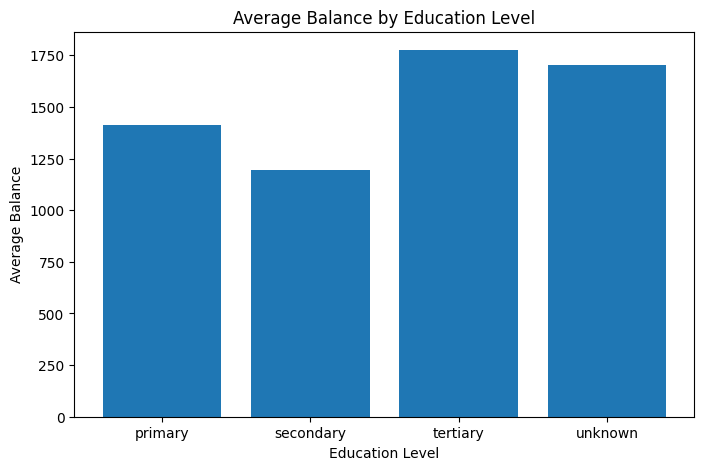

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(
    education_balance["education"],
    education_balance["mean"]
)

plt.title("Average Balance by Education Level")
plt.xlabel("Education Level")
plt.ylabel("Average Balance")

plt.show()

## Hive Question 9(A): Impact of Previous Campaign Outcomes

### Objective
Evaluate how outcomes from previous marketing campaigns influence current term deposit subscription rates.

In [ ]:
poutcome_analysis = (
    client_info.groupby("poutcome")["y"]
    .apply(lambda x: (x == "yes").mean() * 100)
    .reset_index(name="Subscription Rate (%)")
)

poutcome_analysis

,poutcome,Subscription Rate (%)
0,failure,12.857143
1,other,19.289340
2,success,64.341085
3,unknown,9.095816


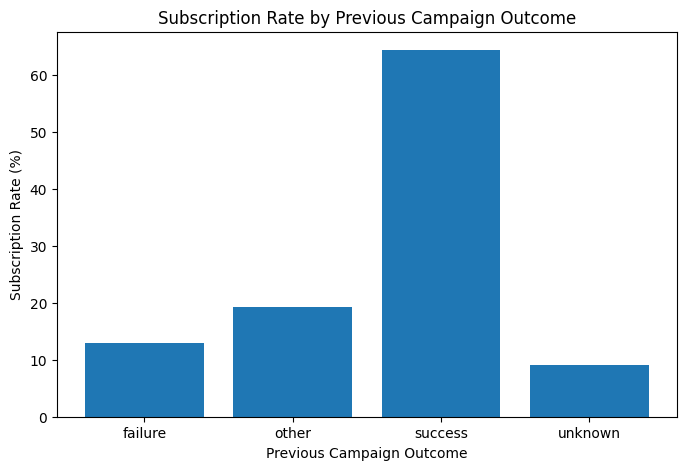

In [ ]:
plt.figure(figsize=(8,5))

plt.bar(
    poutcome_analysis["poutcome"],
    poutcome_analysis["Subscription Rate (%)"]
)

plt.title("Subscription Rate by Previous Campaign Outcome")
plt.xlabel("Previous Campaign Outcome")
plt.ylabel("Subscription Rate (%)")

plt.show()

## Hive Question 9(B): Average Contact Duration by Subscription Status

### Objective
Compare customer interaction durations between subscribers and non-subscribers.

In [ ]:
duration_comparison = (
    client_info.groupby("y")["duration"]
    .mean()
    .reset_index()
)

duration_comparison.columns = [
    "Subscription Status",
    "Average Duration"
]

duration_comparison

,Subscription Status,Average Duration
0,no,226.347500
1,yes,552.742802


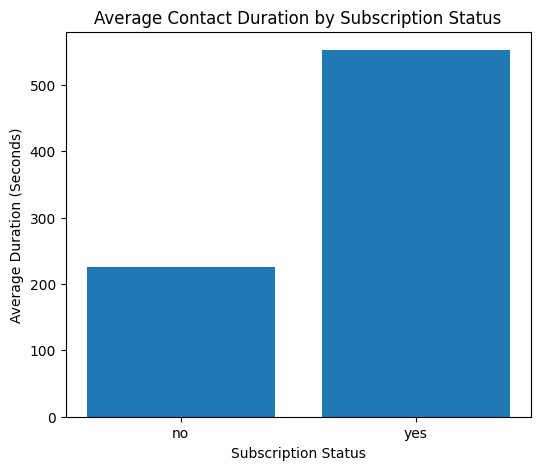

In [ ]:
plt.figure(figsize=(6,5))

plt.bar(
    duration_comparison["Subscription Status"],
    duration_comparison["Average Duration"]
)

plt.title("Average Contact Duration by Subscription Status")
plt.xlabel("Subscription Status")
plt.ylabel("Average Duration (Seconds)")

plt.show()

# Key Findings

* The banking dataset containing 4,521 customer records was successfully ingested and analyzed.
* Average account balances varied significantly across job categories, with certain professions demonstrating stronger financial positions.
* Housing loan ownership and credit default patterns differed across education levels.
* Marketing campaign performance varied by month, campaign outcome, and customer segment.
* Previous successful campaign outcomes were strongly associated with higher term deposit subscription rates.
* Contact duration showed a noticeable relationship with customer subscription behavior.

# Learnings

* Understood the role of distributed data management in banking analytics.
* Learned how Hadoop-style processing can be used for large-scale data ingestion and transformation.
* Applied Hive-style analytical queries to extract business insights from structured banking data.
* Performed aggregation, filtering, correlation analysis, trend analysis, and customer behavior analysis.
* Gained practical experience in transforming raw banking data into actionable business insights.

# Conclusion

This project demonstrated the application of Hadoop and Hive concepts for banking data analysis and management. Various analytical techniques were used to explore customer demographics, financial behavior, loan patterns, marketing campaign effectiveness, and subscription outcomes. The results highlight how distributed data processing frameworks can support data-driven decision-making in the banking sector by efficiently handling large datasets and generating valuable business insights.
